# ML

## Libraries

In [121]:
import pandas as pd 
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
import joblib 
import warnings
warnings.filterwarnings("ignore")

## Load & Get Data

In [2]:
data = load_wine()

In [3]:
data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [4]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)

df['target'] = data.target

df['target_names'] = df['target'].map(lambda x: data.target_names[x])

df.to_csv('wine_dataset.csv', index=False)

In [5]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_names
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2,class_2


## EDA 

### General Exploring 

In [9]:
df.shape

(178, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [11]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_names                    0
dtype: int64

### Visualizing 

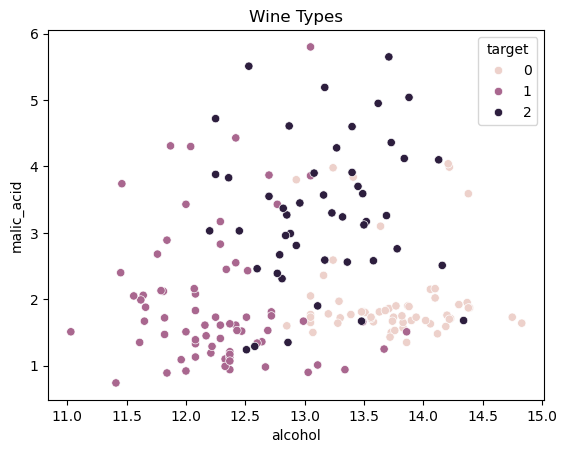

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# با target_names، محورها و افسانه (legend) قشنگ‌تر میشه
sns.scatterplot(data=df, x='alcohol', y='malic_acid', hue='target')
plt.title('Wine Types')
plt.show()

## Data cleaning 

In [118]:
sc = StandardScaler()

In [119]:
sc.fit_transform(x)

array([[ 0.78980621,  0.68550197,  0.70724686, ...,  0.01119018,
         1.05695159,  0.3124203 ],
       [ 1.49390724,  1.52930533,  0.26860595, ..., -0.38367031,
         1.01457831,  1.06077633],
       [-0.08723191,  0.42517966,  1.21899459, ..., -0.82240418,
        -0.42611337, -0.46778066],
       ...,
       [ 1.70390229, -0.4186237 ,  0.0492855 , ...,  1.06415147,
         0.54847218,  2.54793491],
       [-0.38369551, -0.72382916, -0.38935541, ...,  0.01119018,
        -0.77922407, -0.8021525 ],
       [-0.81603824,  0.10202093,  0.34171277, ..., -0.69078402,
         1.08520045, -0.98366865]])

## Data preprocessing 

In [30]:
df_1 = df_1.sample(frac=1, random_state=42).reset_index(drop=True)

- train test split 

In [127]:
x = df_1.iloc[: , :-1]

In [128]:
y = df_1.iloc[ :,-1]

In [39]:
x_train , x_test , y_train , y_test = train_test_split(x,y,train_size=0.8)

## Train model 

### LogisticRegression

In [68]:
lr = LogisticRegression()

In [69]:
lr.fit(x_train,y_train)

LogisticRegression()

In [70]:
y_pred = lr.predict(x_test)

In [71]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.91      1.00      0.95        10
           2       1.00      1.00      1.00        12

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [72]:
print(accuracy_score(y_test,y_pred))

0.9722222222222222


In [75]:
joblib.dump(lr,'logestic_wine.pkl')

['logestic_wine.pkl']

- find best hypeerparametr

In [63]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

In [65]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [67]:
grid.fit(x_train, y_train)

# نمایش بهترین پارامترها
print(grid.best_params_)
print(grid.best_score_)

{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
0.9578817733990148


### XGboost

In [77]:
xg  = XGBClassifier()

In [78]:
xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [79]:
y_pred = xg.predict(x_test)

In [83]:
print(classification_report(y_test,y_pred))
print()
print('*'*100)
print('*'*100)
print()
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.91      1.00      0.95        10
           2       1.00      0.92      0.96        12

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


****************************************************************************************************
****************************************************************************************************

0.9722222222222222


In [84]:
joblib.dump(xg,'xgboost_model.pkl')

['xgboost_model.pkl']

### random forest 

In [94]:
rf = RandomForestClassifier()

In [95]:
rf.fit(x_train,y_train)

RandomForestClassifier()

In [96]:
y_pred = rf.predict(x_test)

In [97]:
print(classification_report(y_test,y_pred))
print()
print('*'*100)
print('*'*100)
print()
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        12

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


****************************************************************************************************
****************************************************************************************************

1.0


In [100]:
rf_score = cross_val_score(rf, x, y, cv=5).mean()
print(f"RF CV Score: {rf_score:.4f}")

RF CV Score: 0.9887


In [102]:
joblib.dump(rf,'random.pkl')

['random.pkl']

### Naive Bayes 

In [104]:
from sklearn.naive_bayes import GaussianNB

In [105]:
nv = GaussianNB()

In [106]:
nv.fit(x_train , y_train)

GaussianNB()

In [107]:
y_pred = nv.predict(x_test)

In [108]:
print(classification_report(y_test,y_pred))
print()
print('*'*100)
print('*'*100)
print()
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        12

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


****************************************************************************************************
****************************************************************************************************

1.0


In [109]:
nv_score = cross_val_score(nv, x, y, cv=5).mean()
print(f"NV CV Score: {nv_score:.4f}")

NV CV Score: 0.9830


## train 2 

- with another preprocessing

In [120]:
x_train , x_test , y_train , y_test = train_test_split(x,y,train_size=0.8)

In [122]:
r = RandomForestClassifier()

In [123]:
r.fit(x_train,y_train)

RandomForestClassifier()

In [124]:
y_pred = r.predict(x_test)

In [125]:
print(classification_report(y_test,y_pred))
print()
print('*'*100)
print('*'*100)
print()
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.94      0.97        18
           2       1.00      1.00      1.00         9

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.98      0.97      0.97        36


****************************************************************************************************
****************************************************************************************************

0.9722222222222222
